In [264]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [265]:
df = pd.read_csv('BOM.csv')
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [266]:
df = df.loc[df['RainTomorrow'].notna()].copy()

In [267]:
if df['RainTomorrow'].dtype == "object":
    df["RainTomorrow_Discrete"] = df['RainTomorrow'].replace({"No": 0, "Yes": 1})
else:
    df["RainTomorrow_Discrete"] = np.where(df['RainTomorrow'] > 0, 1, 0)

C:\Users\arya\AppData\Local\Temp\ipykernel_23256\1025783404.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["RainTomorrow_Discrete"] = df['RainTomorrow'].replace({"No": 0, "Yes": 1})


In [268]:
df.head(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainTomorrow_Discrete
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No,0
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No,0
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No,0
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No,0
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No,0


In [269]:
df["Date"] = pd.to_datetime(df["Date"])
df["month"] = df["Date"].dt.month

In [270]:
num_features = df.select_dtypes(include="number").columns

for feature in num_features:
    if df[feature].isna().sum() != 0:
        monthly_median = df.groupby("month")[feature].transform("median")
        df[feature] = df[feature].fillna(monthly_median)

In [271]:
if "RainToday" in df:
    df["RainToday"] = df["RainToday"].replace({"No": 0, "Yes": 1})

C:\Users\arya\AppData\Local\Temp\ipykernel_23256\3232680897.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["RainToday"] = df["RainToday"].replace({"No": 0, "Yes": 1})


In [272]:
object_features = list(df.select_dtypes(include="object").columns)
remove_cols = object_features + ["Date", 'RainTomorrow']

df.drop(columns=remove_cols, inplace=True, errors="ignore")

In [273]:
df.fillna(0, inplace=True)

In [274]:
df.head(5)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow_Discrete,month
0,13.4,22.9,0.6,7.4,10.2,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,0.0,0,12
1,7.4,25.1,0.0,7.4,10.2,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,0.0,0,12
2,12.9,25.7,0.0,7.4,10.2,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,0.0,0,12
3,9.2,28.0,0.0,7.4,10.2,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,0.0,0,12
4,17.5,32.3,1.0,7.4,10.2,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,0.0,0,12


In [275]:
X = df.loc[:, df.columns != 'RainTomorrow_Discrete']
Y = df['RainTomorrow_Discrete']

In [276]:
X_temp, X_test, Y_temp, Y_test = train_test_split(X, Y, test_size=0.15, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_temp, Y_temp, test_size=0.1765, random_state=42)

In [298]:
X_train

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Cloud9am,Cloud3pm,Temp9am,RainToday,month
118920,8.6,18.3,0.2,2.6,6.4,44.0,17.0,28.0,75.0,71.0,1024.0,2.0,5.0,12.2,0.0,8
64538,13.2,19.8,0.0,4.6,11.3,37.0,15.0,20.0,57.0,51.0,1022.4,6.0,2.0,14.9,0.0,12
32862,11.1,24.9,0.2,0.6,9.3,54.0,9.0,15.0,62.0,32.0,1018.3,2.0,4.0,17.4,0.0,9
8309,8.6,21.4,0.0,2.2,6.0,30.0,9.0,13.0,69.0,32.0,1026.1,6.0,3.0,12.9,0.0,6
14363,4.9,15.5,0.0,1.8,6.6,37.0,9.0,24.0,84.0,51.0,1019.6,7.0,8.0,8.5,0.0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64983,10.2,17.6,0.0,5.0,0.5,41.0,28.0,28.0,67.0,73.0,1015.8,7.0,8.0,13.4,0.0,3
134195,11.7,24.2,0.0,5.8,8.7,35.0,0.0,19.0,92.0,57.0,1011.5,5.0,5.0,14.2,0.0,3
92951,9.4,24.9,0.0,3.0,7.9,33.0,7.0,26.0,71.0,48.0,1018.5,4.0,5.0,16.3,0.0,8
8296,11.3,19.4,0.0,3.2,7.1,20.0,15.0,9.0,69.0,49.0,1028.7,7.0,5.0,14.3,0.0,5


### section a

In [277]:
corr = X_train.corr().abs()

In [278]:
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
upper_triangle = corr.mask(~mask)

In [279]:
high_corr_cols = []

for c in upper_triangle.columns:
    if (upper_triangle[c] > 0.95).any():
        high_corr_cols.append(c)

In [280]:
for c in high_corr_cols:
    related = upper_triangle.index[upper_triangle[c] > 0.95].tolist()
    print(f"- {c} is highly correlated with {related}")

- Pressure3pm is highly correlated with ['Pressure9am']
- Temp3pm is highly correlated with ['MaxTemp']


In [281]:
for dataset in [X_train, X_val, X_test]:
    dataset.drop(columns=high_corr_cols, inplace=True)

### section b

In [282]:
std = StandardScaler()
train_scaled = std.fit_transform(X_train)
val_scaled = std.transform(X_val)
test_scaled = std.transform(X_test)

In [283]:
knn_model = KNeighborsClassifier(n_neighbors=5)

feature_selector = SequentialFeatureSelector(
    knn_model,
    n_features_to_select=10,
    direction="forward",
    cv=3,
    n_jobs=-1
)

<div dir="rtl" align="right">
چون تعداد نمونه ها زیاده من 7000 تا رو به عنوان sample انتخاب کردم
</div>


In [284]:
sample_X = train_scaled[:7000]
sample_y = Y_train[:7000]

feature_selector.fit(sample_X, sample_y)

selected_mask = feature_selector.get_support()
chosen_features = X_train.columns[selected_mask].to_list()

print(chosen_features)

['MinTemp', 'MaxTemp', 'Rainfall', 'Sunshine', 'WindGustSpeed', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Temp9am', 'month']


In [285]:
train_selected = feature_selector.transform(train_scaled)
val_selected = feature_selector.transform(val_scaled)
test_selected = feature_selector.transform(test_scaled)

### section c

In [286]:
candidate_k = list(range(1, 25, 2))
best_k = None
best_score = -1
scores = []

for k in candidate_k:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(train_selected, Y_train)

    preds = model.predict(val_selected)
    score = accuracy_score(Y_val, preds)

    scores.append(score)

    if score > best_score:
        best_score = score
        best_k = k


In [287]:
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(train_selected, Y_train)

test_pred = best_knn.predict(test_selected)
test_acc = accuracy_score(Y_test, test_pred)

In [288]:
print(best_knn)
print(test_acc)

KNeighborsClassifier(n_neighbors=23)
0.8442496132026818


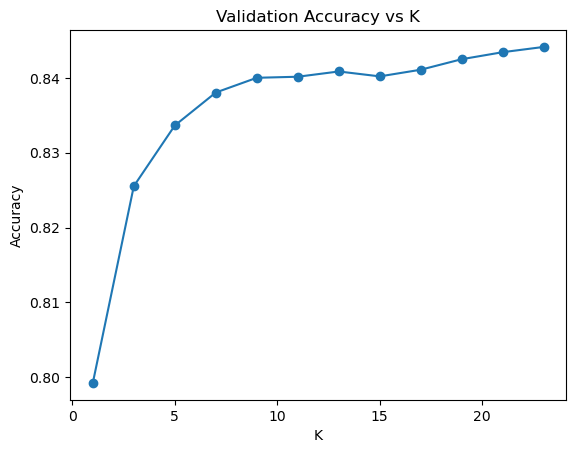

In [289]:
plt.plot(candidate_k, scores, marker="o")
plt.title("Validation Accuracy vs K")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

### section d

In [290]:
rasht = pd.DataFrame([ [np.nan]*len(chosen_features) ], columns=chosen_features)

values = {
    "MinTemp": 22.0,
    "MaxTemp": 30.0,
    "Rainfall": 0.0,
    "WindSpeed9am": 2.0,
    "WindSpeed3pm": 12.0,
    "Humidity9am": 73.0,
    "Humidity3pm": 47.0,
    "Pressure9am": 1017.0,
    "Pressure3pm": 1014.0,
    "Cloud9am": 2.0,
    "Cloud3pm": 1.0,
    "Temp9am": 22.0,
    "Temp3pm": 30.0,
    "RainToday": 0.0
}

In [291]:
for k in values:
    if k in rasht.columns:
        rasht.at[0, k] = values[k]

rasht

,MinTemp,MaxTemp,Rainfall,Sunshine,WindGustSpeed,Humidity9am,Humidity3pm,Pressure9am,Temp9am,month
0,22.0,30.0,0.0,NaN,NaN,73.0,47.0,1017.0,22.0,NaN


In [292]:
month_now = 6
for col in rasht.columns:
    if pd.isna(rasht.at[0, col]):
        median_val = df.loc[df["month"] == month_now, col].median()
        rasht.at[0, col] = median_val

In [293]:
rasht

,MinTemp,MaxTemp,Rainfall,Sunshine,WindGustSpeed,Humidity9am,Humidity3pm,Pressure9am,Temp9am,month
0,22.0,30.0,0.0,6.0,33.0,73.0,47.0,1017.0,22.0,6.0


In [294]:
scaler_temp = StandardScaler()
scaler_temp.fit(X_train[chosen_features])
rasht_scaled = scaler_temp.transform(rasht)


In [295]:
pred = best_knn.predict(rasht_scaled)[0]
probs = best_knn.predict_proba(rasht_scaled)[0]

In [296]:
print(pred)

0


In [297]:
print(probs[1]*100)

8.695652173913043


### section e

<div dir="rtl" align="right">
الگوریتم K-Nearest Neighbors علاوه بر طبقه‌بندی باینری، می‌تواند از طریق متد predict_proba() احتمال وقوع بارش را نیز تخمین بزند. این احتمال بر اساس نسبت همسایگان نزدیک دارای بارش محاسبه می‌شود و نسبت به پیش‌بینی قطعی، امکان تصمیم‌گیری مبتنی بر ریسک را فراهم می‌کند. انتخاب k بر کیفیت تخمین تأثیرگذار است؛ k بزرگ‌تر تخمین پایدارتری ایجاد می‌کند و k کوچک‌تر حساسیت بیشتری دارد. با این حال، چون مدل روی داده‌های استرالیا آموزش دیده، تخمین احتمال برای رشت ممکن است دقیق نباشد و برای کاربرد واقعی نیاز به بازآموزی روی داده‌های محلی ایران دارد.الگوریتم K-Nearest Neighbors علاوه بر طبقه‌بندی باینری، می‌تواند از طریق متد predict_proba() احتمال وقوع بارش را نیز تخمین بزند. این احتمال بر اساس نسبت همسایگان نزدیک دارای بارش محاسبه می‌شود و نسبت به پیش‌بینی قطعی، امکان تصمیم‌گیری مبتنی بر ریسک را فراهم می‌کند. انتخاب k بر کیفیت تخمین تأثیرگذار است؛ k بزرگ‌تر تخمین پایدارتری ایجاد می‌کند و k کوچک‌تر حساسیت بیشتری دارد. با این حال، چون مدل روی داده‌های استرالیا آموزش دیده، تخمین احتمال برای رشت ممکن است دقیق نباشد و برای کاربرد واقعی نیاز به بازآموزی روی داده‌های محلی ایران دارد.
</div>
